## Check if the packages are installed

In [14]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")

pandas is installed
matplotlib is installed
numpy is installed


## Import Packages

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os
from sklearn.decomposition import PCA

from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import tensorflow as tf



## Load dataset

In [16]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

## Visualization

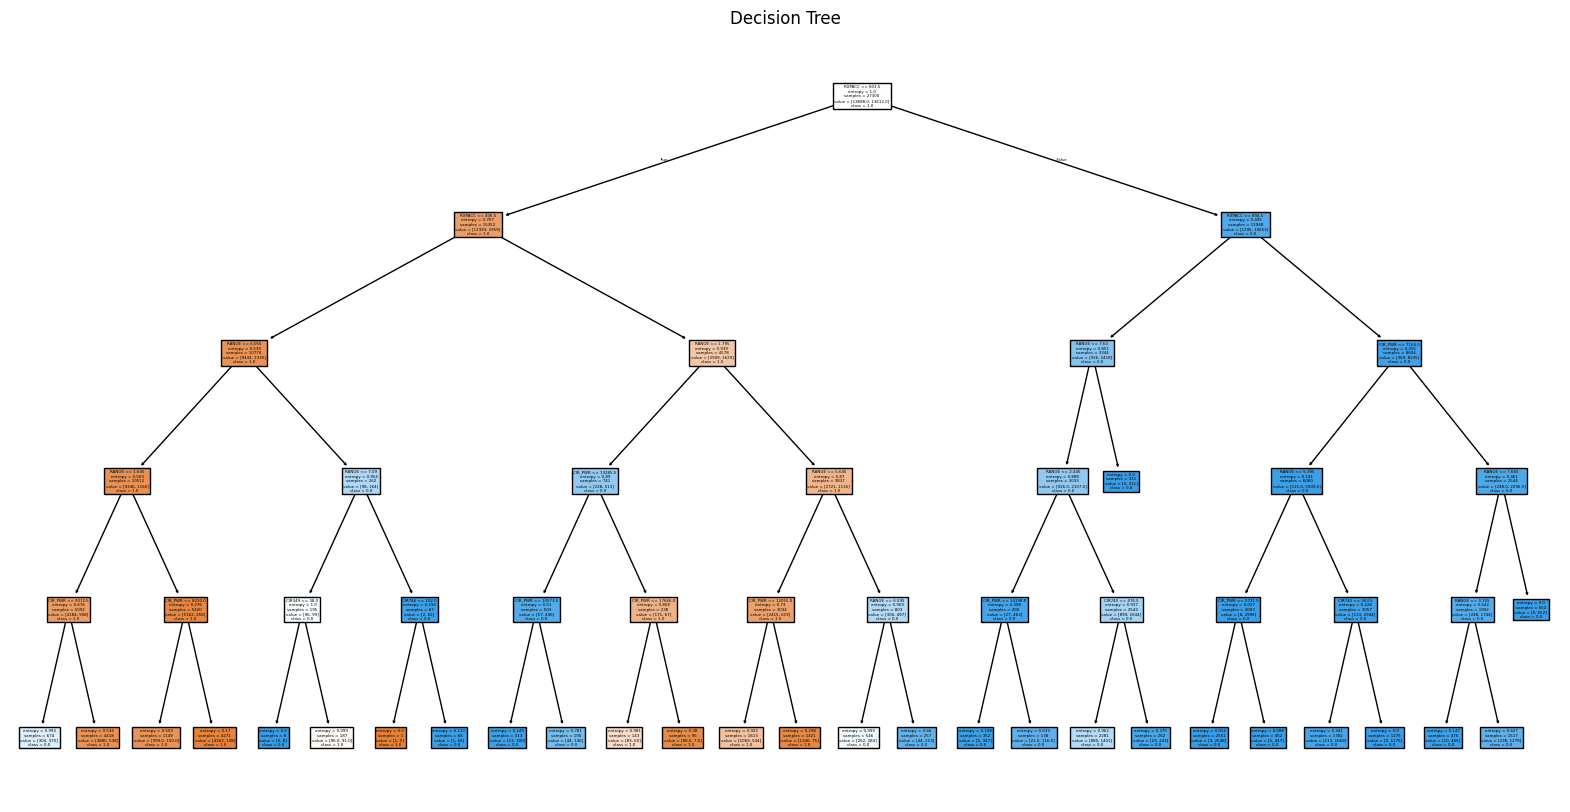

In [17]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X_train.columns, class_names=y_train.unique().astype(str)) 
plt.title("Decision Tree")
plt.show()


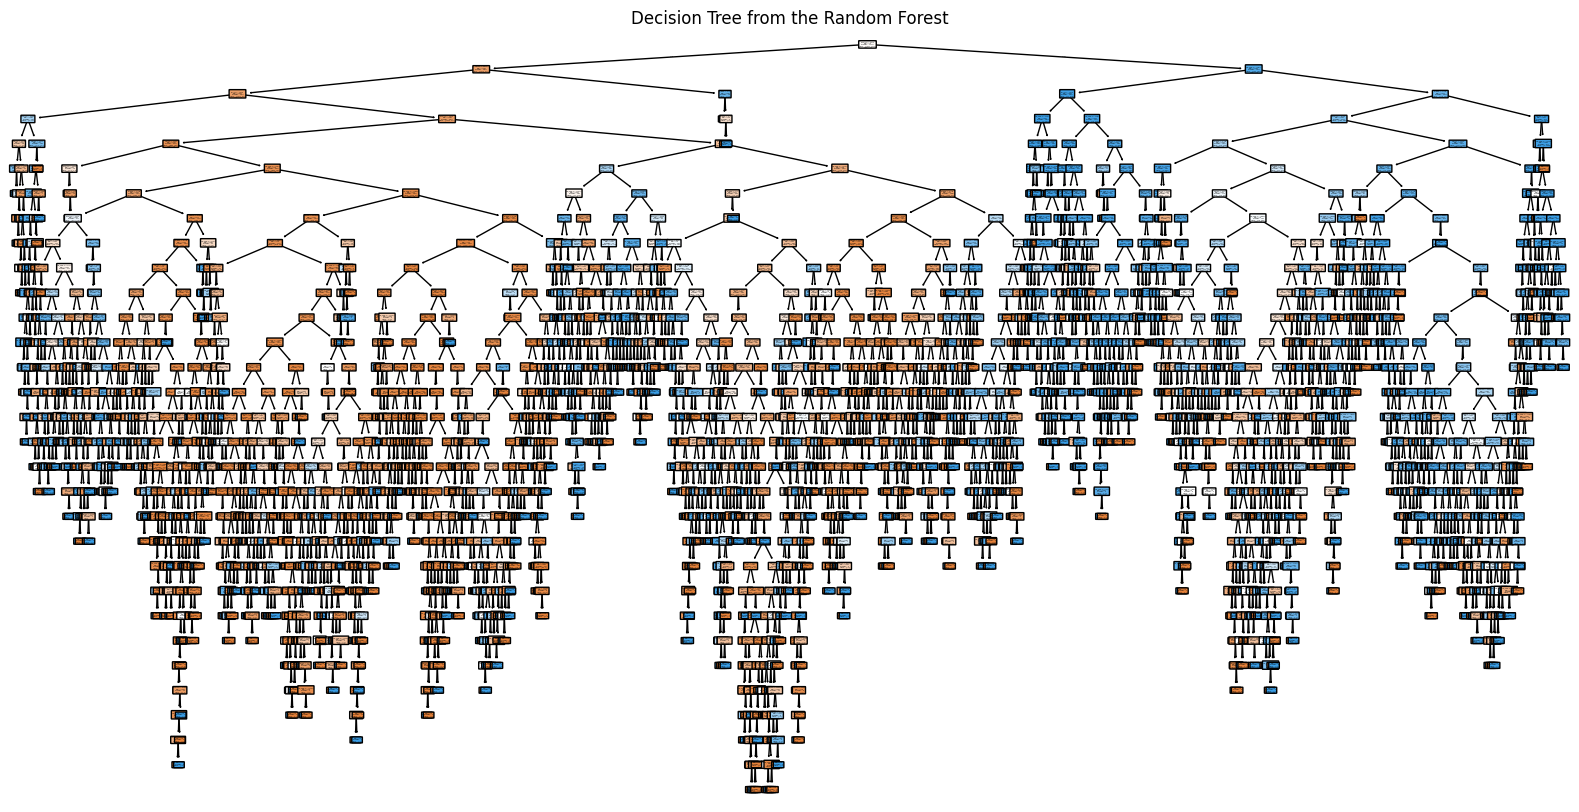

In [18]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

tree = rfc.estimators_[0]
plt.figure(figsize=(20, 10)) 
plot_tree(tree, 
          feature_names=X_train.columns,  
          class_names=y_train.unique().astype(str),  
          filled=True,              
          rounded=True)             
plt.title("Decision Tree from the Random Forest")
plt.show()

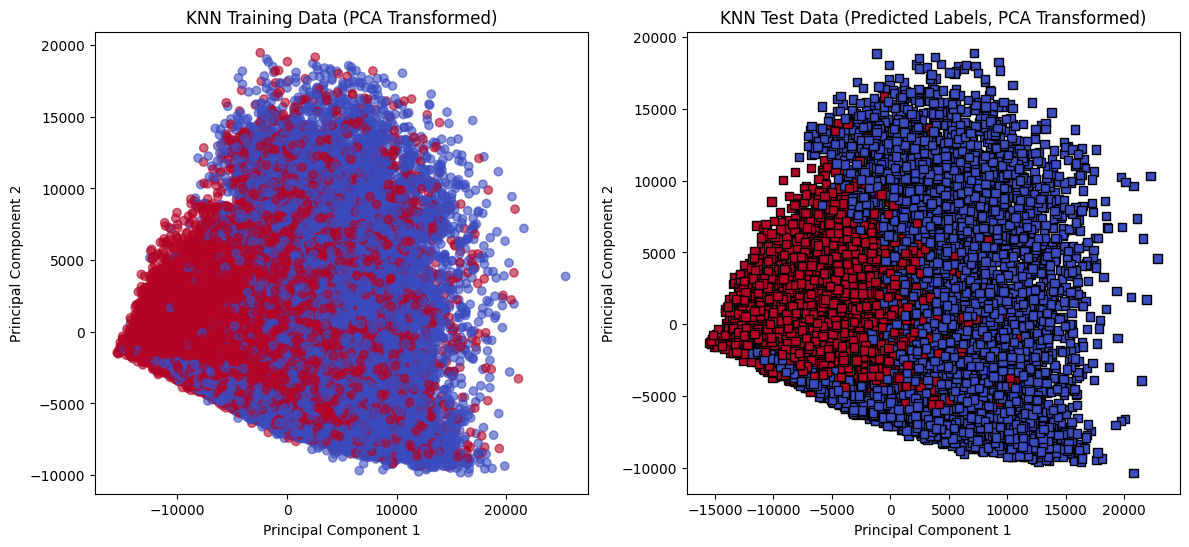

In [19]:


pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_test_pca = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])

k_best = 20
clf_pca = KNeighborsClassifier(n_neighbors=k_best)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train_pca['PC1'], X_train_pca['PC2'], c=y_train, cmap='coolwarm', alpha=0.6)
axes[0].set_title("KNN Training Data (PCA Transformed)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

scatter = axes[1].scatter(X_test_pca['PC1'], X_test_pca['PC2'], c=y_pred_pca, cmap='coolwarm', edgecolor='black', marker='s')
axes[1].set_title("KNN Test Data (Predicted Labels, PCA Transformed)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.show()


In [20]:
hidden_layer_sizes = [(5, 5, 5)]
trainAcc = []
testAcc = []

clf6 = MLPClassifier(solver='adam', hidden_layer_sizes=(5, 5, 5), learning_rate='adaptive', random_state=1, max_iter=1000)
clf6.fit(X_train, y_train)
Y_predTrain = clf6.predict(X_train)
Y_predTest = clf6.predict(X_test)

trainAcc.append(accuracy_score(y_train, Y_predTrain))
testAcc.append(accuracy_score(y_test, Y_predTest))

print(f'hidden_layer_sizes={(5, 5, 5)}, Training Accuracy: {accuracy_score(y_train, Y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, Y_predTest):.4f}')



hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8519, Test Accuracy: 0.8511


# Range Prediction

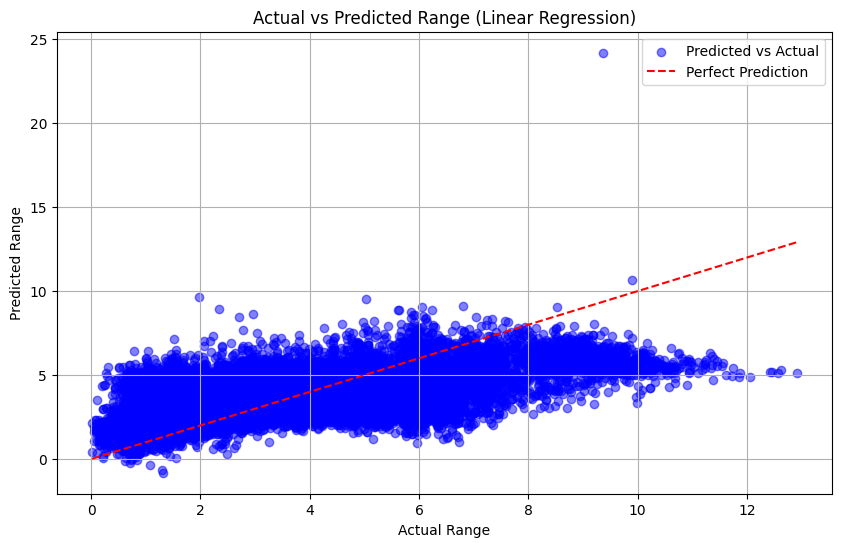

In [21]:
file_directory = "./Cleaned_Data"
original_df_range = pd.read_csv(os.path.join(file_directory,"Range_Cleaned_Data.csv"))

X = original_df_range.drop(['RANGE', 'NLOS'], axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.35, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(X_train_range, y_train_range)

y_pred_range = regr.predict(X_test_range)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_range, y_pred_range, color='blue', alpha=0.5, label='Predicted vs Actual')

plt.plot([min(y_test_range), max(y_test_range)], [min(y_test_range), max(y_test_range)], color='red', linestyle='--', label="Perfect Prediction")

plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted Range (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/25
854/854 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6604 - mean_absolute_error: 0.6437 - mean_squared_error: 0.6604 - val_loss: 0.5525 - val_mean_absolute_error: 0.5858 - val_mean_squared_error: 0.5525
Epoch 2/25
854/854 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5602 - mean_absolute_error: 0.5835 - mean_squared_error: 0.5602 - val_loss: 0.5513 - val_mean_absolute_error: 0.5817 - val_mean_squared_error: 0.5513
Epoch 3/25
854/854 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5294 - mean_absolute_error: 0.5711 - mean_squared_error: 0.5294 - val_loss: 0.5344 - val_mean_absolute_error: 0.5732 - val_mean_squared_error: 0.5344
Epoch 4/25
854/854 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5287 - mean_absolute_error: 0.5689 - mean_squared_error: 0.5287 - val_loss: 0.5285 - val_mean_absolute_error: 0.5792 - val_mean_squared_error: 0.5285
Epoch 5/25
854/854 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5119 - mean_absolute_error: 0.5631 - mean_squared_error: 0.5119 - val_loss: 0.5416 - val_m

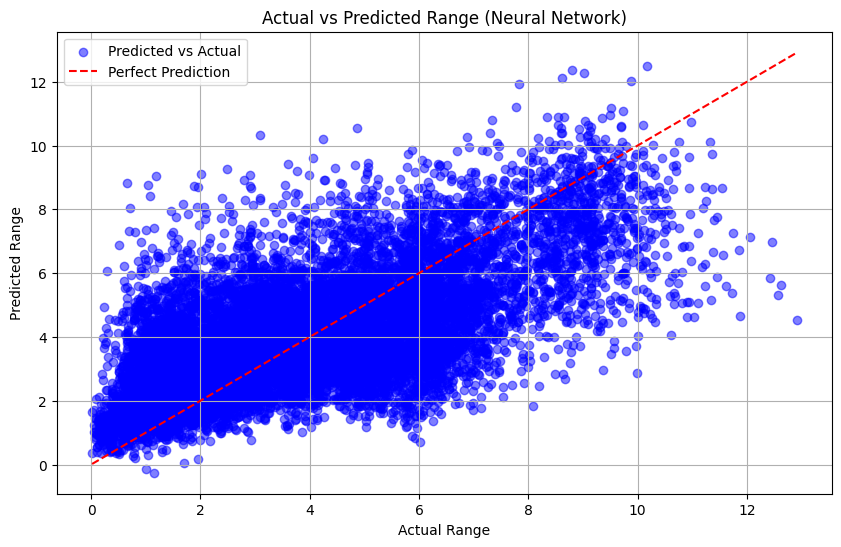

In [22]:
ann = tf.keras.models.Sequential()

ann.add(tf.keras.layers.Dense(units=64, activation='relu'))  # Increased neurons
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))  # New layer
ann.add(tf.keras.layers.Dense(units=64, activation='relu'))  # New layer
ann.add(tf.keras.layers.Dense(units=1))  # Output layer remains the same

scaler = StandardScaler()
scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train_range)
X_test_scaled = scaler_X.transform(X_test_range)

# Fit and transform the target variable
y_train_scaled = scaler_y.fit_transform(y_train_range.values.reshape(-1, 1)) 
y_test_scaled = scaler_y.transform(y_test_range.values.reshape(-1, 1)) 


ann.compile(optimizer = 'adam', loss = 'mean_squared_error',metrics=['mean_absolute_error', 'mean_squared_error'])

model = ann.fit(X_train_scaled, y_train_scaled, 
                batch_size=32, 
                epochs=25,
                validation_data=(X_test_scaled, y_test_scaled),  # Validation data should be test data
                shuffle=True)


# Predict on the test set using the trained model
y_test_pred_scaled = model.model.predict(X_test_scaled)

# Reverse the scaling for predictions to get the original scale
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# Reverse the scaling for the true values to get the original scale
y_test_true = scaler_y.inverse_transform(y_test_scaled)

# Plot Actual vs Predicted Range
plt.figure(figsize=(10, 6))
plt.scatter(y_test_true, y_test_pred, color='blue', alpha=0.5, label='Predicted vs Actual')

# Perfect prediction line
plt.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], color='red', linestyle='--', label="Perfect Prediction")

# Labels and title
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted Range (Neural Network)")

# Show legend and grid
plt.legend()
plt.grid(True)
plt.show()

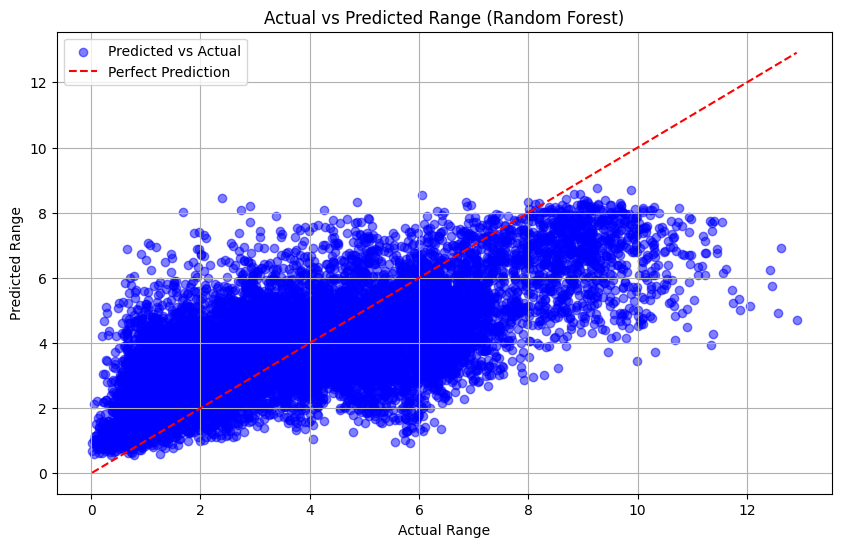

In [23]:

# Initialize and train the Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=40, min_samples_split=25, min_samples_leaf=1, max_features='log2', max_depth=25, bootstrap=True, random_state=42)
regressor.fit(X_train_range, y_train_range)

# Make predictions on the test set
y_pred_range = regressor.predict(X_test_range)

# Plot Actual vs Predicted Range
plt.figure(figsize=(10, 6))
plt.scatter(y_test_range, y_pred_range, color='blue', alpha=0.5, label='Predicted vs Actual')

# Perfect prediction line
plt.plot([min(y_test_range), max(y_test_range)], [min(y_test_range), max(y_test_range)], color='red', linestyle='--', label="Perfect Prediction")

# Labels and title
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted Range (Random Forest)")

# Show legend and grid
plt.legend()
plt.grid(True)
plt.show()